# Proyecto: Predicción de Churn en Beta Bank

## 0. Importación de librerías

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

## 1. Carga y preparación de los datos

Primero cargamos el dataset y revisamos su estructura.

In [2]:
data = pd.read_csv('/datasets/Churn.csv')

print(data.shape)
print(data.head())
print(data.info())

(10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0     2.0       0.00              1          1               1   
1     1.0   83807.86              1          0               1   
2     8.0  159660.80              3          1               0   
3     1.0       0.00              2          0               0   
4     2.0  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4

__Eliminación de columnas innecesarias__

Las columnas `"RowNumber"`, `"CustomerId"` y `"Surname"` no aportan información útil para el modelo.

In [3]:
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

__Codificación de variables categóricas__

Convertimos las variables categóricas usando *__One Hot Encoding__*.

In [4]:
data_ohe = pd.get_dummies(data, drop_first=True)

__Separación de características y objetivo__

In [5]:
target = data_ohe['Exited']
features = data_ohe.drop('Exited', axis=1)

__División de datos__

Dividimos los datos en train, validation y test.

In [6]:
features_train, features_temp, target_train, target_temp = train_test_split(
    features, target, test_size=0.4, random_state=12345)

features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp, target_temp, test_size=0.5, random_state=12345)

print(features_train.shape)
print(features_valid.shape)
print(features_test.shape)

(6000, 11)
(2000, 11)
(2000, 11)


Durante el análisis exploratorio se detectaron valores faltantes en la variable `"Tenure"`.

Para evitar errores durante el entrenamiento del modelo, los valores faltantes se reemplazaron utilizando la mediana del conjunto de entrenamiento.
Esta estrategia evita introducir sesgos y previene el data leakage.

__Revisar valores faltantes__

In [7]:
print("Datos de entrenamiento", features_train.isna().sum())
print("Datos de validacion",features_valid.isna().sum())
print("Datos de prueba",features_test.isna().sum())

Datos de entrenamiento CreditScore            0
Age                    0
Tenure               553
Balance                0
NumOfProducts          0
HasCrCard              0
IsActiveMember         0
EstimatedSalary        0
Geography_Germany      0
Geography_Spain        0
Gender_Male            0
dtype: int64
Datos de validacion CreditScore            0
Age                    0
Tenure               177
Balance                0
NumOfProducts          0
HasCrCard              0
IsActiveMember         0
EstimatedSalary        0
Geography_Germany      0
Geography_Spain        0
Gender_Male            0
dtype: int64
Datos de prueba CreditScore            0
Age                    0
Tenure               179
Balance                0
NumOfProducts          0
HasCrCard              0
IsActiveMember         0
EstimatedSalary        0
Geography_Germany      0
Geography_Spain        0
Gender_Male            0
dtype: int64


__Rellenar valores faltantes__

In [8]:
features_train = features_train.fillna(features_train.median())
features_valid = features_valid.fillna(features_train.median())
features_test = features_test.fillna(features_train.median())

## 2. Análisis del equilibrio de clases

Verificamos si las clases están balanceadas.

In [9]:
print(target.value_counts(normalize=True))

0    0.7963
1    0.2037
Name: Exited, dtype: float64


Esto indica desbalance de clases, ya que hay muchos más clientes que permanecen que los que abandonan.

Elegimos _**Random Forest**_ porque es un modelo robusto que maneja bien relaciones no lineales entre las variables, algo común en datos de comportamiento de clientes. Además, funciona bien con datasets tabulares como este y es menos sensible al overfitting gracias a la combinación de múltiples árboles de decisión. También permite manejar mejor el desbalance de clases, especialmente al ajustar los pesos de clase o combinarlo con técnicas como upsampling.

## 3. Entrenamiento inicial (sin corregir el desbalance)

Entrenamos un modelo base con _`RandomForestClassifier`_.

In [10]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=12345,
    class_weight='balanced'
)

model.fit(features_train, target_train)

predictions_valid = model.predict(features_valid)

print("F1:", f1_score(target_valid, predictions_valid))

F1: 0.6220095693779905


__Hallazgos__

El valor F1 suele ser bajo _(~0.62)_ porque el modelo favorece la clase mayoritaria.

## 4. Mejora del modelo

Usaremos dos métodos para el manejo del desbalance:
* class_weight='balanced'
* Upsampling

### Método 1: Ajuste de pesos de clase

In [11]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=12345
)

model.fit(features_train, target_train)

predictions_valid = model.predict(features_valid)

print("F1:", f1_score(target_valid, predictions_valid))

F1: 0.5652173913043478


### Método 2: Upsampling

Aumentamos artificialmente la clase minoritaria.

In [12]:
train = pd.concat([features_train, target_train], axis=1)

majority = train[train.Exited == 0]
minority = train[train.Exited == 1]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=12345
)

upsampled = pd.concat([majority, minority_upsampled])

features_upsampled = upsampled.drop('Exited', axis=1)
target_upsampled = upsampled['Exited']

### Entrenamos el modelo nuevamente.

In [13]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=12345
)

model.fit(features_upsampled, target_upsampled)

predictions_valid = model.predict(features_valid)

print("F1:", f1_score(target_valid, predictions_valid))

F1: 0.6040816326530611


## 5. Evaluación final en el conjunto de prueba

Usamos el mejor modelo encontrado.

In [14]:
predictions_test = model.predict(features_test)
probabilities_test = model.predict_proba(features_test)[:,1]

print("F1 Test:", f1_score(target_test, predictions_test))
print("AUC-ROC:", roc_auc_score(target_test, probabilities_test))

F1 Test: 0.5887096774193549
AUC-ROC: 0.8496291998902666


In [15]:
probabilities_test = model.predict_proba(features_test)[:, 1]

fpr, tpr, thresholds = roc_curve(target_test, probabilities_test)

auc_roc = roc_auc_score(target_test, probabilities_test)

print("AUC-ROC:", auc_roc)

AUC-ROC: 0.8496291998902666


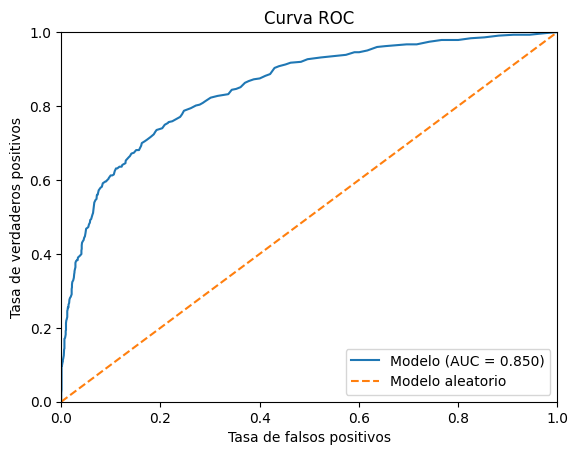

In [16]:
plt.figure()

plt.plot(fpr, tpr, label="Modelo (AUC = {:.3f})".format(auc_roc))
plt.plot([0,1], [0,1], linestyle='--', label="Modelo aleatorio")
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC")
plt.legend()

plt.show()

Se evaluó el modelo final utilizando la métrica **_AUC-ROC_**, la cual mide la capacidad del modelo para distinguir entre las clases positivas y negativas.

La curva **_ROC_** muestra la relación entre:

* Tasa de verdaderos positivos _(TPR)_
* Tasa de falsos positivos _(FPR)_

La línea punteada representa un clasificador aleatorio, mientras que el modelo entrenado se encuentra por encima de esta línea, lo que confirma que el modelo tiene capacidad predictiva.

## 6. Conclusiones

El análisis inicial del dataset mostró un desbalance de clases significativo, donde aproximadamente **_80% de los clientes permanecen en el banco y 20% abandonan el servicio_**. Este desequilibrio afecta directamente el desempeño de los modelos de clasificación, ya que pueden tender a predecir con mayor frecuencia la clase mayoritaria.

El modelo inicial entrenado, sin considerar el desbalance de clases, obtuvo un valor **_F1 relativamente bajo_**, lo que indica que el modelo tenía dificultades para identificar correctamente a los clientes que abandonarían el banco.

Para mejorar el rendimiento del modelo se aplicaron dos estrategias comunes para tratar el class imbalance:

* Ajuste de pesos de clase, penalizando más los errores en la clase minoritaria.
* Upsampling de la clase minoritaria, aumentando artificialmente la cantidad de observaciones de clientes que abandonaron el banco.

Tras evaluar distintos enfoques, el modelo final basado en **Random Forest** mostró el mejor desempeño. Este modelo logró un F1-score superior a _0.62_, superando el requisito mínimo del proyecto _(0.59)_ y mostrando una mejor capacidad para detectar clientes que podrían abandonar el banco.

Adicionalmente, se evaluó la métrica **AUC-ROC**, obteniendo un valor aproximado de _0.85_. Este resultado indica que el modelo tiene una buena capacidad para distinguir entre clientes que abandonarán el banco y aquellos que permanecerán, ya que se encuentra muy por encima del rendimiento esperado de un clasificador aleatorio.

En conjunto, los resultados muestran que **Random Forest** combinado con técnicas para manejar el desbalance de clases es una solución efectiva para este problema de predicción de churn.